# Verification: IgE Antigen Pulse Binding (Harmon et al., 2017)

Validates both BNGL files in this folder:

1. **Primary** (`_harmon2017.bngl`): Full signaling model.
   Checks that pulse/wash degranulation reproduces the
   desensitization (short I) and priming (long I) pattern
   from Fig. 4.

2. **Variant** (`_simplified.bngl`): Receptor occupancy submodel.
   Compares BNG ODE output against an independent SciPy ODE
   for simple reversible binding under escalating-dose
   pulse/wash protocol.

In [1]:
import subprocess, os, glob
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

os.chdir(os.path.dirname(os.path.abspath('__file__'))
         if '__file__' in dir() else '.')

## 1. Full signaling model — Fig. 4 validation

Run the primary BNGL and extract $H(S_1)$ and $H(S_2)$
for each quiescence interval $I$. The model should show
desensitization ($H(S_2) < H(S_1)$) for short $I$ and
priming ($H(S_2) > H(S_1)$) for long $I$.

In [2]:
# Run the primary model
primary = 'antigen_pulses_harmon2017.bngl'
r = subprocess.run(['bionetgen', 'run', '-i', primary],
                   capture_output=True, text=True, timeout=120)
assert r.returncode == 0, f'BNG failed: {r.stderr[-300:]}'

H_tot = 1e6  # molecules/cell
intervals = [5, 30, 60, 120, 240]  # min
stem = 'antigen_pulses_harmon2017'

# H(S1): degranulation at end of first 5-min pulse
d = np.loadtxt(f'{stem}_p1_5.gdat', comments='#')
# degranulation column is last
HS1 = d[-1, -1] / H_tot * 100  # percent

# H(S2) for each I: degranulation at end of p3_I
# (H(loc~out) was reset to 0 before S2)
HS2 = {}
for I in intervals:
    d = np.loadtxt(f'{stem}_p3_{I}.gdat', comments='#')
    HS2[I] = d[-1, -1] / H_tot * 100

print(f'H(S1) = {HS1:.2f}%')
for I in intervals:
    ratio = HS2[I] / HS1 if HS1 > 0 else 0
    label = 'desensitized' if ratio < 0.9 else (
            'primed' if ratio > 1.1 else 'similar')
    print(f'  I={I:>3d} min: H(S2) = {HS2[I]:5.2f}%  '
          f'(S2/S1 = {ratio:.2f}, {label})')

# Cleanup generated files (keep reference/ intact)
for p in glob.glob(f'{stem}_p*'):
    os.remove(p)
for p in glob.glob(f'{stem}.net'):
    os.remove(p)

H(S1) = 10.30%
  I=  5 min: H(S2) =  3.55%  (S2/S1 = 0.34, desensitized)
  I= 30 min: H(S2) =  6.77%  (S2/S1 = 0.66, desensitized)
  I= 60 min: H(S2) =  9.21%  (S2/S1 = 0.89, desensitized)
  I=120 min: H(S2) = 16.13%  (S2/S1 = 1.57, primed)
  I=240 min: H(S2) = 39.85%  (S2/S1 = 3.87, primed)


## 2. Simplified receptor model — independent ODE validation

The simplified model tracks $B(t)$ = BoundIgE under
pseudo-first-order kinetics:

$$\frac{dB}{dt} = k_{\text{on}} \cdot A_{\text{tot}} \cdot
(R_T - B) - k_{\text{off}} \cdot B \quad\text{(pulse)}$$

$$\frac{dB}{dt} = -k_{\text{off}} \cdot B
\quad\text{(wash)}$$

In [3]:
# Parameters (matching the BNGL file)
NA = 6.02214e23
ncells = 20000
V = 100.0e-6 / ncells
mwtAg = 22400
koff_s = 0.001264          # /s
KD = 7.435e-10             # M
kon_s = (koff_s/KD)/(NA*V) # /molecule/s
IgEtot = 9838

# Pulse protocol: (start_s, end_s, Agconc_ng_ml)
pulses = [(0, 300, 10), (300, 600, 0),
          (600, 900, 30), (900, 1200, 0),
          (1200, 1500, 100), (1500, 2400, 0)]

def ode_binding(t, y, kon_Agtot, koff):
    B = y[0]
    F = IgEtot - B
    return [kon_Agtot * F - koff * B]

# Solve piecewise
t_py, B_py = [], []
B0 = 0.0
for t0, t1, Agconc in pulses:
    if Agconc > 0:
        Agtot = Agconc * 1e-6 * (NA * V) / mwtAg
        kon_Agtot = kon_s * Agtot
    else:
        kon_Agtot = 0.0
    dt = t1 - t0
    n = max(int(dt), 100)
    t_eval = np.linspace(t0, t1, n + 1)
    sol = solve_ivp(ode_binding, (t0, t1), [B0],
                    args=(kon_Agtot, koff_s),
                    t_eval=t_eval, method='LSODA',
                    rtol=1e-10, atol=1e-12)
    t_py.extend(sol.t.tolist())
    B_py.extend(sol.y[0].tolist())
    B0 = sol.y[0, -1]

t_py = np.array(t_py)
B_py = np.array(B_py)
print(f'Independent ODE: {len(t_py)} points, '
      f'B_final = {B_py[-1]:.1f}')

Independent ODE: 2406 points, B_final = 2583.7


In [4]:
# Load BNG output for simplified model
bng = np.loadtxt(
    'reference/antigen_pulses_harmon2017'
    '_simplified_pulses.gdat', comments='#')
t_bng = bng[:, 0]
# Column order: time, FreeIgE, BoundIgE, FreeAg, TmpAg
B_bng = bng[:, 2]
print(f'BNG output: {len(t_bng)} points, '
      f'B_final = {B_bng[-1]:.1f}')

BNG output: 2401 points, B_final = 2583.7


## Comparison plots

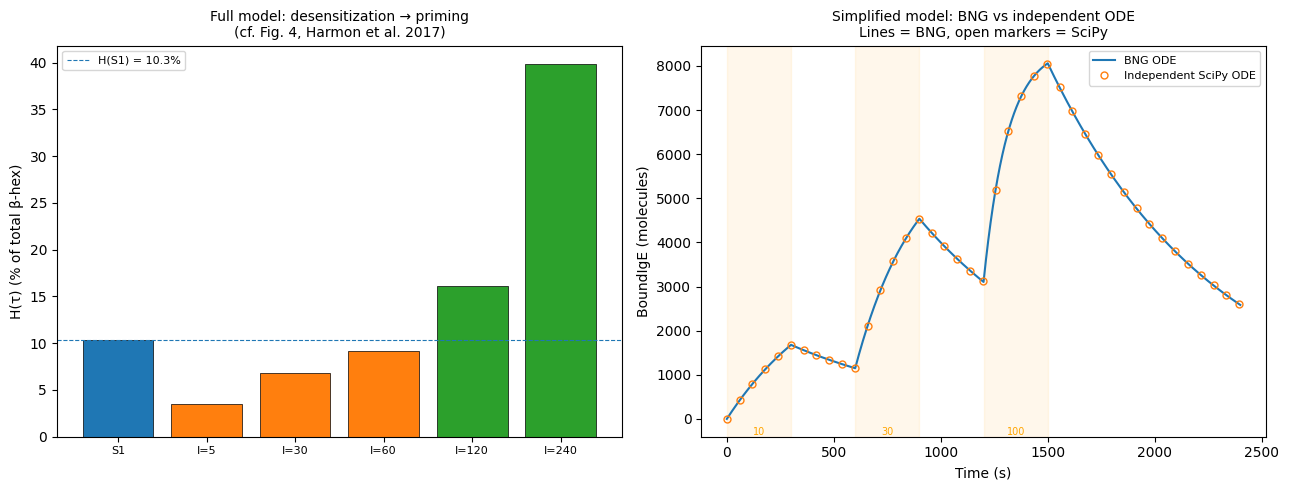

Saved verify_harmon2017.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel A: Full model, Fig. 4 degranulation ---
ax = axes[0]
x_pos = np.arange(len(intervals) + 1)
labels = ['S1'] + [f'I={I}' for I in intervals]
vals = [HS1] + [HS2[I] for I in intervals]
colors = ['C0'] + ['C1' if HS2[I] < HS1 else 'C2'
          for I in intervals]
ax.bar(x_pos, vals, color=colors, edgecolor='k', lw=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('H(τ) (% of total β-hex)')
ax.set_title('Full model: desensitization → priming\n'
             '(cf. Fig. 4, Harmon et al. 2017)',
             fontsize=10)
ax.axhline(HS1, ls='--', color='C0', lw=0.8,
           label=f'H(S1) = {HS1:.1f}%')
ax.legend(fontsize=8)

# --- Panel B: Simplified model, BNG vs independent ---
ax = axes[1]
ax.plot(t_bng, B_bng, 'C0-', lw=1.5, label='BNG ODE')
# Subsample independent solution for markers
skip = max(len(t_py) // 40, 1)
ax.plot(t_py[::skip], B_py[::skip], 'o', mfc='none',
        mec='C1', ms=5, label='Independent SciPy ODE')
# Shade pulse intervals
for t0, t1, Ag in pulses:
    if Ag > 0:
        ax.axvspan(t0, t1, alpha=0.08, color='orange')
        ax.text((t0+t1)/2, ax.get_ylim()[0],
               f'{Ag}', ha='center', va='bottom',
               fontsize=7, color='orange')
ax.set_xlabel('Time (s)')
ax.set_ylabel('BoundIgE (molecules)')
ax.set_title('Simplified model: BNG vs independent ODE\n'
             'Lines = BNG, open markers = SciPy',
             fontsize=10)
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig('verify_harmon2017.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved verify_harmon2017.png')

In [6]:
# --- Error summary ---
print('=== Full model (Fig. 4 pattern) ===')
desens_ok = all(HS2[I] < HS1 for I in [5, 30])
prime_ok = all(HS2[I] > HS1 for I in [120, 240])
print(f'  Desensitization (I=5,30): '
      f'{"PASS" if desens_ok else "FAIL"}')
print(f'  Priming (I=120,240):      '
      f'{"PASS" if prime_ok else "FAIL"}')

print()
print('=== Simplified model (BNG vs SciPy ODE) ===')
# Interpolate Python solution at BNG time points
B_py_interp = np.interp(t_bng, t_py, B_py)
mask = B_bng > 10  # where signal is meaningful
if mask.sum() > 0:
    rel_err = np.abs(B_bng[mask] - B_py_interp[mask]
                     ) / B_py_interp[mask]
    print(f'  Max relative error:  {rel_err.max():.6f}')
    print(f'  Mean relative error: {rel_err.mean():.6f}')
    simplified_ok = rel_err.max() < 0.01
else:
    simplified_ok = False
print(f'  {"PASS" if simplified_ok else "FAIL"}: '
      f'BNG matches independent ODE')

print()
if desens_ok and prime_ok and simplified_ok:
    print('OVERALL PASS')
else:
    print('OVERALL: CHECK failures above')

=== Full model (Fig. 4 pattern) ===
  Desensitization (I=5,30): PASS
  Priming (I=120,240):      PASS

=== Simplified model (BNG vs SciPy ODE) ===
  Max relative error:  0.000000
  Mean relative error: 0.000000
  PASS: BNG matches independent ODE

OVERALL PASS
